# ERCOT Load Forecasting

## 04 — Weather Models (Oracle-Weather Diagnostic)

**This is a diagnostic experiment, not a production day-ahead model.** The weather
columns are historical *realized* weather — what actually happened — not forecasts that
would have been known at prediction time. The question we are answering is:

> If the model had accurate weather information, would it reduce the systematic
> cold-snap forecasting failures found in notebook 02?

If the answer is yes, the next step is to replace realized weather with archived
*forecast* weather that was available before each target hour.

Everything else stays identical to notebook 02: chronological split (development
2022–2024, test 2025), TimeSeriesSplit cross-validation, the same GridSearchCV grids,
and a focus on Gradient Boosting and XGBoost.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from xgboost import XGBRegressor

## 1. Load the merged dataset

`model_data_weather.csv` was built in notebook 03: the notebook-02 features plus 12
city-specific weather columns (temperature, relative humidity, apparent temperature for
Houston, Dallas, San Antonio, Austin).

In [2]:
model_df = pd.read_csv("../data/processed/model_data_weather.csv", index_col="timestamp")

#MIXED UTC OFFSETS IN THE CSV: PARSE TO UTC FIRST, THEN CONVERT (SAME LESSON AS NOTEBOOK 02)
model_df.index = pd.to_datetime(model_df.index, utc=True).tz_convert("America/Chicago")

features_base = [
    "hour",
    "day_of_week",
    "month",
    "load_24h_ago",
    "load_168h_ago",
]

# the 12 weather columns, named exactly as notebook 03 created them
weather_columns = [
    f"{variable}_{city}"
    for variable in ["temperature_2m", "relative_humidity_2m", "apparent_temperature"]
    for city in ["austin", "dallas", "houston", "san_antonio"]
]

features_weather = features_base + weather_columns

print(model_df.shape)
print("missing weather values:", model_df[weather_columns].isna().sum().sum())

(34896, 30)
missing weather values: 0


## 2. Chronological split

Same as notebook 02: everything up to the end of 2024 is development data (used for
cross-validation and tuning), all of 2025 is the untouched test year.

In [3]:
#SAME CHRONOLOGICAL SPLIT AS NOTEBOOK 02 - NO RANDOM SPLITTING
dev_df = model_df.loc[:"2024-12-31"]
test_df = model_df.loc["2025-01-01":]

y_dev = dev_df["ERCOT"]
y_test = test_df["ERCOT"]

tscv = TimeSeriesSplit(n_splits=3)

print("Development:", dev_df.shape)
print("Test:", test_df.shape)

Development: (26135, 30)
Test: (8761, 30)


## 3. Naive baseline (reference)

Same 24-hour persistence baseline as notebook 02, so every result in this notebook can
be read against it.

In [4]:
y_pred_naive = test_df["load_24h_ago"]

naive_mae = mean_absolute_error(y_test, y_pred_naive)
naive_rmse = root_mean_squared_error(y_test, y_pred_naive)
naive_r2 = r2_score(y_test, y_pred_naive)

print("Naive Baseline - Test")
print("MAE:", naive_mae)
print("RMSE:", naive_rmse)
print("R2:", naive_r2)

Naive Baseline - Test
MAE: 2518.3207039629033
RMSE: 3607.49642078547
R2: 0.8734274825855979


## 4. Gradient boosting — without vs with weather

Both feature sets get the identical tuning budget (same grid, same folds), so the
comparison is fair: the only difference is the features.

In [5]:
#SAME GRID AS NOTEBOOK 02
param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [5, 10, 14],
}

gb_base_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid_gb,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    refit=True,
)

gb_base_search.fit(dev_df[features_base], y_dev)

y_pred_gb_base = gb_base_search.best_estimator_.predict(test_df[features_base])

gb_base_mae = mean_absolute_error(y_test, y_pred_gb_base)
gb_base_rmse = root_mean_squared_error(y_test, y_pred_gb_base)
gb_base_r2 = r2_score(y_test, y_pred_gb_base)

print("Best parameters:", gb_base_search.best_params_)
print("\nGradient Boosting (no weather) - Test")
print("MAE:", gb_base_mae)
print("RMSE:", gb_base_rmse)
print("R2:", gb_base_r2)

Best parameters: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 14, 'n_estimators': 200}

Gradient Boosting (no weather) - Test
MAE: 2330.2970025367895
RMSE: 3331.848510791334
R2: 0.8920312447807672


In [6]:
gb_weather_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid_gb,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    refit=True,
)

gb_weather_search.fit(dev_df[features_weather], y_dev)

y_pred_gb_weather = gb_weather_search.best_estimator_.predict(test_df[features_weather])

gb_weather_mae = mean_absolute_error(y_test, y_pred_gb_weather)
gb_weather_rmse = root_mean_squared_error(y_test, y_pred_gb_weather)
gb_weather_r2 = r2_score(y_test, y_pred_gb_weather)

print("Best parameters:", gb_weather_search.best_params_)
print("\nGradient Boosting (oracle weather) - Test")
print("MAE:", gb_weather_mae)
print("RMSE:", gb_weather_rmse)
print("R2:", gb_weather_r2)

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 200}

Gradient Boosting (oracle weather) - Test
MAE: 2166.6000675041923
RMSE: 2694.432855088696
R2: 0.9293906308808149


## 5. XGBoost — without vs with weather

In [7]:
#SAME GRID AS NOTEBOOK 02
param_grid_xgb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_base_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid_xgb,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    refit=True,
)

xgb_base_search.fit(dev_df[features_base], y_dev)

y_pred_xgb_base = xgb_base_search.best_estimator_.predict(test_df[features_base])

xgb_base_mae = mean_absolute_error(y_test, y_pred_xgb_base)
xgb_base_rmse = root_mean_squared_error(y_test, y_pred_xgb_base)
xgb_base_r2 = r2_score(y_test, y_pred_xgb_base)

print("Best parameters:", xgb_base_search.best_params_)
print("\nXGBoost (no weather) - Test")
print("MAE:", xgb_base_mae)
print("RMSE:", xgb_base_rmse)
print("R2:", xgb_base_r2)

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}

XGBoost (no weather) - Test
MAE: 2319.771450357893
RMSE: 3319.61300005175
R2: 0.8928227736967924


In [8]:
xgb_weather_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid_xgb,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    refit=True,
)

xgb_weather_search.fit(dev_df[features_weather], y_dev)

y_pred_xgb_weather = xgb_weather_search.best_estimator_.predict(test_df[features_weather])

xgb_weather_mae = mean_absolute_error(y_test, y_pred_xgb_weather)
xgb_weather_rmse = root_mean_squared_error(y_test, y_pred_xgb_weather)
xgb_weather_r2 = r2_score(y_test, y_pred_xgb_weather)

print("Best parameters:", xgb_weather_search.best_params_)
print("\nXGBoost (oracle weather) - Test")
print("MAE:", xgb_weather_mae)
print("RMSE:", xgb_weather_rmse)
print("R2:", xgb_weather_r2)

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

XGBoost (oracle weather) - Test
MAE: 2206.7340145991607
RMSE: 2733.5017070992653
R2: 0.9273281361217588


## 6. Results comparison

For reference, notebook 02 (no weather, slightly different because each search refits)
got: Gradient Boosting MAE ≈ 2330, XGBoost MAE ≈ 2320, naive baseline MAE ≈ 2518.

In [9]:
model_summary = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Gradient Boosting (no weather)",
        "Gradient Boosting (oracle weather)",
        "XGBoost (no weather)",
        "XGBoost (oracle weather)",
    ],
    "MAE": [naive_mae, gb_base_mae, gb_weather_mae, xgb_base_mae, xgb_weather_mae],
    "RMSE": [naive_rmse, gb_base_rmse, gb_weather_rmse, xgb_base_rmse, xgb_weather_rmse],
    "R2": [naive_r2, gb_base_r2, gb_weather_r2, xgb_base_r2, xgb_weather_r2],
})

model_summary.round(3)

,Model,MAE,RMSE,R2
0,Naive Baseline,2518.321,3607.496,0.873
1,Gradient Boosting (no weather),2330.297,3331.849,0.892
2,Gradient Boosting (oracle weather),2166.600,2694.433,0.929
3,XGBoost (no weather),2319.771,3319.613,0.893
4,XGBoost (oracle weather),2206.734,2733.502,0.927


## 7. Cold-snap error analysis

The whole point of this notebook: notebook 02's ten worst errors were all huge
underpredictions on 2025-01-06 and 2025-02-19. Does oracle weather fix those hours?
We compare the XGBoost model with and without weather.

In [10]:
results = pd.DataFrame({
    "actual": y_test,
    "pred_no_weather": y_pred_xgb_base,
    "pred_weather": y_pred_xgb_weather,
})

results["abs_err_no_weather"] = (results["actual"] - results["pred_no_weather"]).abs()
results["abs_err_weather"] = (results["actual"] - results["pred_weather"]).abs()

#MAE ON THE FULL TEST YEAR vs THE COLD-SNAP PERIODS
periods = {
    "full test year": results,
    "Jan-Feb 2025": results.loc["2025-01":"2025-02"],
    "2025-01-06 (worst day 1)": results.loc["2025-01-06"],
    "2025-02-19 (worst day 2)": results.loc["2025-02-19"],
}

for name, subset in periods.items():
    print(name)
    print("  no weather MAE:", round(subset["abs_err_no_weather"].mean(), 1))
    print("  weather MAE:   ", round(subset["abs_err_weather"].mean(), 1))

full test year
  no weather MAE: 2319.8
  weather MAE:    2206.7
Jan-Feb 2025
  no weather MAE: 3533.6
  weather MAE:    2916.0
2025-01-06 (worst day 1)
  no weather MAE: 12582.2
  weather MAE:    4632.8
2025-02-19 (worst day 2)
  no weather MAE: 19750.0
  weather MAE:    7513.7


In [11]:
# the ten hours where the NO-weather model was furthest off,
# with the weather model's error on those same hours
worst10 = results.sort_values("abs_err_no_weather", ascending=False).head(10)
worst10.round(0)

,actual,pred_no_weather,pred_weather,abs_err_no_weather,abs_err_weather
timestamp,,,,,
2025-02-19 12:00:00-06:00,76887.0,51169.0,64857.0,25718.0,12030.0
2025-02-19 11:00:00-06:00,76768.0,51119.0,68268.0,25649.0,8500.0
2025-02-19 10:00:00-06:00,76051.0,50929.0,70914.0,25122.0,5137.0
2025-02-19 13:00:00-06:00,76379.0,51331.0,60220.0,25049.0,16160.0
2025-02-19 09:00:00-06:00,75493.0,50847.0,71192.0,24645.0,4300.0
2025-01-06 08:00:00-06:00,67859.0,44006.0,59983.0,23854.0,7876.0
2025-02-19 08:00:00-06:00,74507.0,50725.0,70093.0,23783.0,4415.0
2025-02-19 14:00:00-06:00,75573.0,52278.0,59193.0,23295.0,16380.0
2025-01-06 09:00:00-06:00,67825.0,45310.0,62116.0,22515.0,5709.0


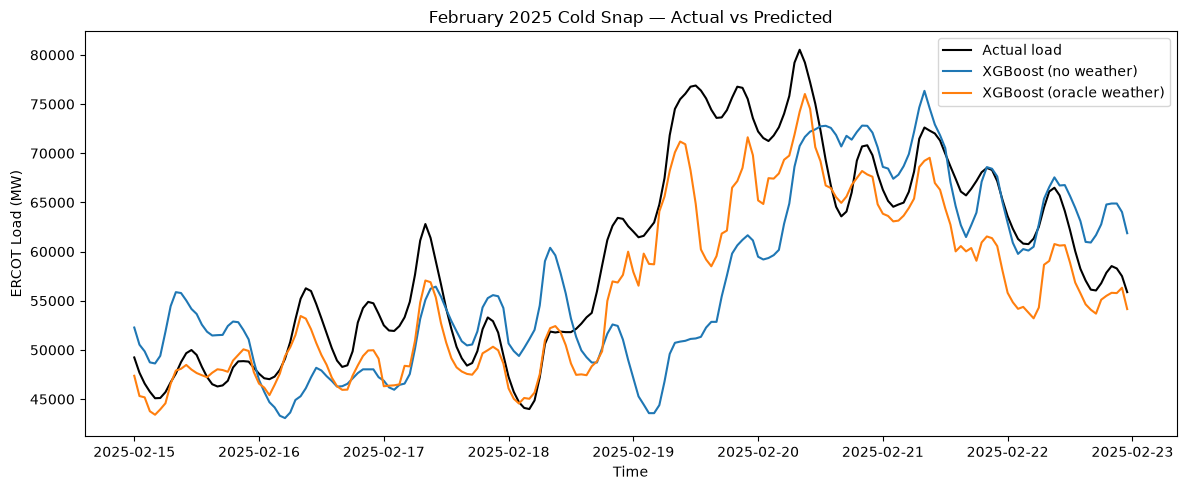

In [12]:
#VISUAL CHECK: THE FEBRUARY 2025 COLD SNAP WEEK
window = results.loc["2025-02-15":"2025-02-22"]

plt.figure(figsize=(12, 5))
plt.plot(window.index, window["actual"], label="Actual load", color="black")
plt.plot(window.index, window["pred_no_weather"], label="XGBoost (no weather)")
plt.plot(window.index, window["pred_weather"], label="XGBoost (oracle weather)")

plt.xlabel("Time")
plt.ylabel("ERCOT Load (MW)")
plt.title("February 2025 Cold Snap — Actual vs Predicted")

plt.legend()
plt.tight_layout()
plt.show()

## 8. Weather-model feature importance

Importance measures how much the trees rely on each feature — what the model *uses*,
not what causes demand.

load_24h_ago                        0.547744
temperature_2m_austin               0.180756
temperature_2m_san_antonio          0.065253
temperature_2m_dallas               0.064830
apparent_temperature_austin         0.044041
apparent_temperature_dallas         0.033458
load_168h_ago                       0.015890
hour                                0.011757
day_of_week                         0.010481
apparent_temperature_houston        0.008277
apparent_temperature_san_antonio    0.005236
month                               0.002696
relative_humidity_2m_houston        0.002588
relative_humidity_2m_austin         0.002112
relative_humidity_2m_dallas         0.001768
relative_humidity_2m_san_antonio    0.001706
temperature_2m_houston              0.001407
dtype: float32


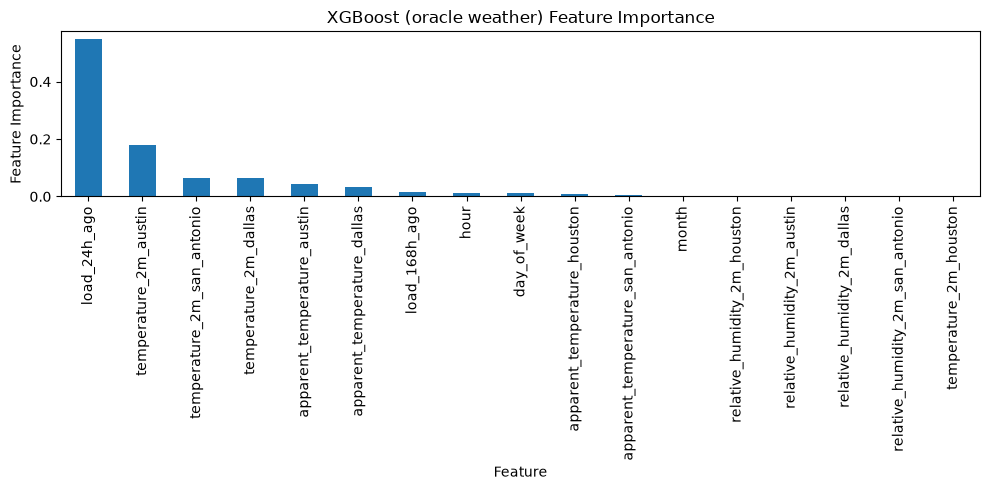

In [13]:
importance = pd.Series(
    xgb_weather_search.best_estimator_.feature_importances_,
    index=features_weather,
)
importance = importance.sort_values(ascending=False)

print(importance)

plt.figure(figsize=(10, 5))
importance.plot(kind="bar")

plt.xlabel("Feature")
plt.ylabel("Feature Importance")
plt.title("XGBoost (oracle weather) Feature Importance")

plt.tight_layout()
plt.show()

## 9. Conclusions

**The hypothesis is supported.** With oracle weather:

- Full-year test MAE improves modestly (XGBoost 2320 → 2207 MW, −5%; Gradient Boosting
  2330 → 2167 MW, −7%), but **RMSE improves ~18%** (3320 → 2734 for XGBoost) and R² rises
  from 0.89 to 0.93 — RMSE punishes large errors, so the gain is concentrated exactly
  where the hypothesis predicted: the extremes.
- On the two cold-snap days that produced notebook 02's worst errors, daily MAE drops
  **~63%**: 2025-01-06 from 12,582 to 4,633 MW, and 2025-02-19 from 19,750 to 7,514 MW.
  The ten worst no-weather hours (all ~22–26 GW underpredictions) shrink to ~4–16 GW.
- Feature importance: `load_24h_ago` still leads (0.55), but temperature now carries
  ~0.31 combined. Humidity contributes almost nothing. One caution: the four city
  temperatures are highly correlated, so the trees split their importance somewhat
  arbitrarily between cities (Austin 0.18 vs Houston 0.001 does **not** mean Houston
  weather is irrelevant).

**Reminder: this is an oracle experiment** — the model saw the weather that actually
happened. A real day-ahead model only has weather *forecasts*. Since accurate weather
clearly fixes the systematic cold-snap failures, the next step is to repeat this with
archived forecast weather available before each target hour, which will tell us how much
of this gain survives forecast error.